# Økonomisk kriminalitet
Formålet her er ikke å undervise i økonomisk kriminalitet.  Eksemplene vi har valgt er derfor syntetiske.

## Datamodell

Vi velger en (svært) enkel datamodell som "til en viss grad" reflekterer økonomisk kriminalitet.

### Noder
Følgende er noder:
- Peroner: Har relasjoner til andre personer, eier konti, og gjennomfører transkasjoner;
- Konto som tilhører en person, og
- Transaksjoner (relasjonene til konto og person gir kontekst).

### Relasjoner (kanter)
- **kjenner** er relasjonen mellom to personer.  Det er åpenbart en (veldig) forenkling av virkeliheten, med godt nok.
- **Kontoeier** er relasjonen fra en konto til en person
- Noden Transaksjon har ENTEN tre kanten (til to konti, én merket **fra** og én merket **til**) og én til en person (som utførte transaksjonen) ELLER to kanter hvor den ene går til personen og den andre til en konto.  I dette tilfellet er transkasjonen merket med "type" som er enten "uttak" eller "innskudd".  I alle tilfeller har transaksjonen et beløp.

Datamodellen vil begrense hva vi kan representere.  Det vil si at med denne enkle modellen er begrenset til å studere "enkle" representasjoner av strukturelle egenskaper.  Mer om det senere.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import uuid
import scipy
from datetime import datetime, timedelta

Norske navn fra SSB som vi legger til nodene

In [3]:
# Norske navn
ordliste = []
with open("data/ordliste.txt", "r") as fd:
    for linje in fd:
        ordliste.append(linje.split("|")[1])
    #
#

Slik ser en person ut, og alle personer har konto (i det minste for tiden).  Alle noder har en UUID4 som identifikator for å sikre oss mot kollisjoner på selve identifikatoren; gjør livet lettere når ting skal settes sammen.

In [4]:
def lag_person_konto(G, 
                     navn=random.choice(ordliste)):
    id = str(uuid.uuid4())
    G.add_node(id, person=True)
    G.nodes[id]["navn"] = navn
    kto = str(uuid.uuid4())
    G.add_node(kto, konto=True)
    G.add_edge(id, kto, kontoeier=True)
    return (id, kto)
#fed

### "Money Mule"
Alle medlemmene i en klikk, unntatt én som vi kaller M, tar ut penger.  Deretter (i tid) setter Bakmannen, som M har relasjon til, et beløp som er noe mindre enn summen av det som er tatt ut.  Det endelige innskuddet skjer naturligvis en stund etter at alle uttakene er gjort.
Uttakene spres utover i tid (fra nå og fremover) og beløpet varierer opp til en grense.  M tar ikke ut penger (han får dem i kontanter).

Vi lager en klikk (og derfor en graf) og setter opp alle realsjonene.

Den skyldige er: Kristen: 211a6652-242e-42a7-b56b-b614ade87893


<Figure size 500x500 with 0 Axes>

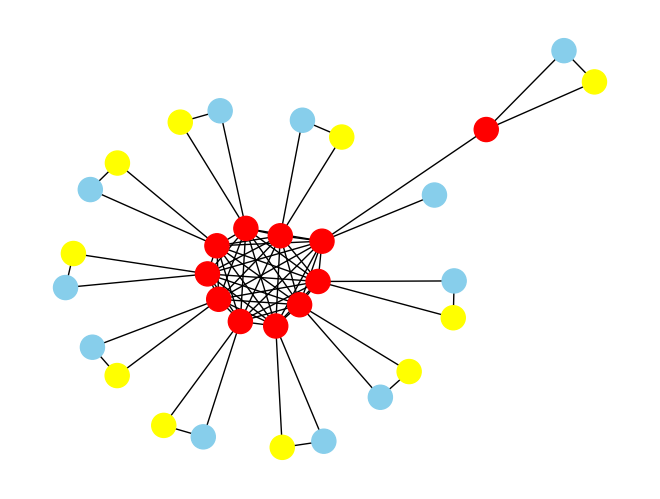

<Figure size 500x500 with 0 Axes>

In [26]:

def lag_money_mule(antall_personer, total_beløp):

    # Uttakene skjer innen dette vinduet
    vindu_uttak = 8 
    #ANtall dager senere innskuddet skjer
    når_skjer_innskuddet = 2
    
    # Lag en klikk.
    uid = []
    for i in range(antall_personer):
        uid.append(str(uuid.uuid4()))
    #
    G = nx.complete_graph(uid)
    # Sett typen til personer
    nx.set_node_attributes(G, True, "person") # OBS rekkefølgen på parametrene!
    nx.set_edge_attributes(G, True, "kjenner")

    # Legg til et navn
    for id in G.nodes:
        G.nodes[id]["navn"] = random.choice(ordliste)
    #
    # Finn den som skal være forbryteren
    M = random.choice(list(G.nodes()))
    print(f"Den skyldige er: {G.nodes[M]["navn"]}: {M}")

    # Lage konti (med random id) til alle deltagere
    noder = list(G.nodes())
    for n in noder:
        kto = f"konto-{n}"
        G.add_node(kto, konto=True)
        G.add_edge(n, kto, kontoeier=True)
    #
    # Legg til en bakmann med konto
    bakmann, bak_kto = lag_person_konto(G, "Bakmann")
    # M kjenner bakmannen
    G.add_edge(M, bakmann, kjenner=True)

    # Alle skal ta ut penger (kontanter)
    folk = []
    for n,p in list(G.nodes(data="person")):
        if p:
            folk.append(n)
        #
    #    
    
    # Disse to skal ikke ta ut penger
    folk.remove(bakmann)
    folk.remove(M)

    bak_beløp = 0 # Totalt beløp tatt ut
    for person in folk:
        id = str(uuid.uuid4())
        beløp = round(total_beløp * random.random(), 2)
        G.add_node(id, 
                   transaksjon = True,
                   uttak = True,
                   beløp=beløp,
                   tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random()))
        bak_beløp += beløp
        G.add_edge(id, person, transaksjon=True)
        # Finn personens konto ved å se på kantene ut fra personen
        for u, v, kto in G.edges([person], data=True):
            if "kontoeier" in kto:
                G.add_edge(id, v, transaksjon=True)
                break
            #
        #
    # for person

    # Bakmannen setter inn pengene, minus ca 25% neste dag
    id = str(uuid.uuid4())
    G.add_node(id,
               transaksjon = True,
               innskudd = True,
               beløp = bak_beløp - round(bak_beløp * random.random() * 0.25, 2), 
               tidspunkt = datetime.now() + timedelta(days=når_skjer_innskuddet))
    G.add_edge(id, bakmann, transaksjon=True)
    G.add_edge(id, bak_kto, transaksjon=True)

    return G
#fed

#
#
G = lag_money_mule(10, 1000)
#
#


# Fjern identifikatorene
#G = nx.convert_node_labels_to_integers(G)
# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#
pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))



Den skyldige er: Kristen: 211a6652-242e-42a7-b56b-b614ade87893


<Figure size 500x500 with 0 Axes>

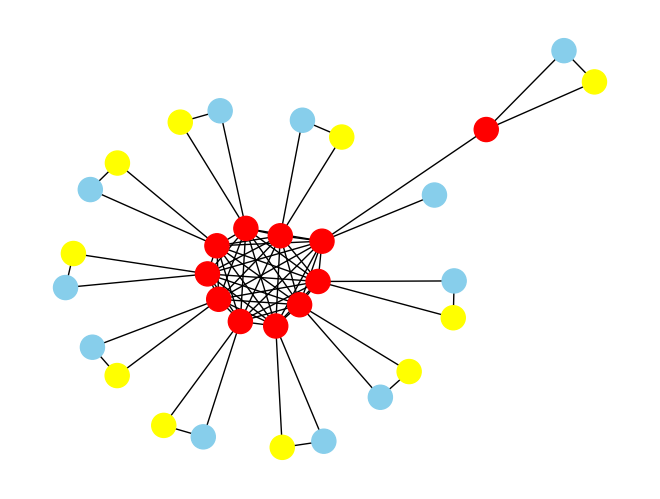

<Figure size 500x500 with 0 Axes>

In [26]:

def lag_money_mule(antall_personer, total_beløp):

    # Uttakene skjer innen dette vinduet
    vindu_uttak = 8 
    #ANtall dager senere innskuddet skjer
    når_skjer_innskuddet = 2
    
    # Lag en klikk.
    uid = []
    for i in range(antall_personer):
        uid.append(str(uuid.uuid4()))
    #
    G = nx.complete_graph(uid)
    # Sett typen til personer
    nx.set_node_attributes(G, True, "person") # OBS rekkefølgen på parametrene!
    nx.set_edge_attributes(G, True, "kjenner")

    # Legg til et navn
    for id in G.nodes:
        G.nodes[id]["navn"] = random.choice(ordliste)
    #
    # Finn den som skal være forbryteren
    M = random.choice(list(G.nodes()))
    print(f"Den skyldige er: {G.nodes[M]["navn"]}: {M}")

    # Lage konti (med random id) til alle deltagere
    noder = list(G.nodes())
    for n in noder:
        kto = f"konto-{n}"
        G.add_node(kto, konto=True)
        G.add_edge(n, kto, kontoeier=True)
    #
    # Legg til en bakmann med konto
    bakmann, bak_kto = lag_person_konto(G, "Bakmann")
    # M kjenner bakmannen
    G.add_edge(M, bakmann, kjenner=True)

    # Alle skal ta ut penger (kontanter)
    folk = []
    for n,p in list(G.nodes(data="person")):
        if p:
            folk.append(n)
        #
    #    
    
    # Disse to skal ikke ta ut penger
    folk.remove(bakmann)
    folk.remove(M)

    bak_beløp = 0 # Totalt beløp tatt ut
    for person in folk:
        id = str(uuid.uuid4())
        beløp = round(total_beløp * random.random(), 2)
        G.add_node(id, 
                   transaksjon = True,
                   uttak = True,
                   beløp=beløp,
                   tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random()))
        bak_beløp += beløp
        G.add_edge(id, person, transaksjon=True)
        # Finn personens konto ved å se på kantene ut fra personen
        for u, v, kto in G.edges([person], data=True):
            if "kontoeier" in kto:
                G.add_edge(id, v, transaksjon=True)
                break
            #
        #
    # for person

    # Bakmannen setter inn pengene, minus ca 25% neste dag
    id = str(uuid.uuid4())
    G.add_node(id,
               transaksjon = True,
               innskudd = True,
               beløp = bak_beløp - round(bak_beløp * random.random() * 0.25, 2), 
               tidspunkt = datetime.now() + timedelta(days=når_skjer_innskuddet))
    G.add_edge(id, bakmann, transaksjon=True)
    G.add_edge(id, bak_kto, transaksjon=True)

    return G
#fed

#
#
G = lag_money_mule(10, 1000)
#
#


# Fjern identifikatorene
#G = nx.convert_node_labels_to_integers(G)
# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#
pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))



### Bakmann
En som knytter sammen flere klikker

<Figure size 500x500 with 0 Axes>

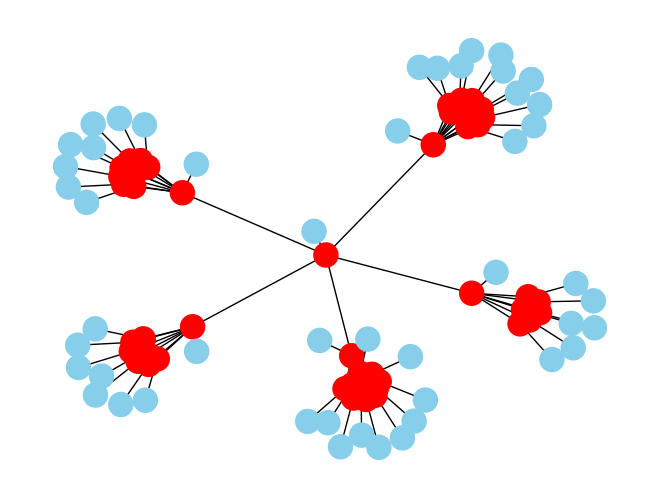

<Figure size 500x500 with 0 Axes>

In [27]:
def bakmann_klikker(antall_klikker, antall_personer):
    assert(antall_klikker > 0)
    assert(antall_personer > 0)
    
    klikker = []
    for k in range(antall_klikker):
        # Lag en klikk med et varierende antall personer rundt antallte
        antall = int(antall_personer + antall_personer/4*random.uniform(-1, 1))
        folk = []
        for f in range(antall):
            folk.append(str(uuid.uuid4()))
        #
        G = nx.complete_graph(folk)
        # Sett typen til personer
        nx.set_node_attributes(G, True, "person") # OBS rekkefølgen på parametrene!
        nx.set_edge_attributes(G, True, "kjenner")
        # Legg til et navn til alle
        for id in G.nodes():
            G.nodes[id]["navn"] = random.choice(ordliste)
        #
        
        # Lage konti (med random id) til alle deltagere
        noder = list(G.nodes())
        for n in noder:
            kto = f"konto-{n}"
            G.add_node(kto, konto=True)
            G.add_edge(n, kto, kontoeier=True)
        #
        klikker.append(G)
    #
    
    komplett = nx.Graph()
    # Legg til en bakmann med konto
    bakmann, bak_kto = lag_person_konto(komplett, "Bakmann")
    
    for klikk in range(len(klikker)):
        # velg en node i klikken
        kopi = list(klikker[klikk].nodes(data=True))        
        random.shuffle(kopi)
        # det skal være minst én person
        for n, d in kopi:
            if "person" in d:
                kontakt = n
                break
            #
        #
        # IDer i klikken som legges til får ID av typen 5-uuid4.
        komplett = nx.union(komplett, klikker[klikk], ("", f"{klikk}-"))
        komplett.add_edge(bakmann, f"{klikk}-{kontakt}", kjenner=True)
    #

    return(komplett)
#fed

G = bakmann_klikker(5, 10)
# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#

pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))


### Utbytte
Én stor transaksjon som tilsynelatende "spittes" i flere og sprer seg utover.  Det starter med ett stort innskudd av kontanter, som så spres utover flere personer.  Tiden går, samtidig som beløpet blir mindre

Dele en pengesum på et antall mennesker, mer eller mindre jevnt, innen et max og et min per person

For N personer, del beløpet opp i N-biter, pluss-minus 20%.  LEgg det som måtte være igjen til én av dem

In [28]:
def del_beløp(beløp, antall):
    penger = []
    igjen = beløp
    for p in range(antall):
        andel = beløp / antall * random.uniform(0.8, 1.2)
        if andel >= igjen:
            penger.append(round(igjen, 2))
            igjen = 0
        else:
            penger.append(round(andel, 2))
            igjen -= andel
        #
    #
    if igjen > 0:
        penger[0] += round(igjen, 2)
    #
    return penger
#


In [29]:

a = del_beløp(5000, 5)
print(a)
print(sum(a))

[1191.74, 1087.17, 836.77, 950.61, 933.7]
4999.99


In [30]:
# Er beløpet mindre enn dette, da beholder du det
MINIMUM_BELØP = 5000
CUT = 15 # inntil, i prosent

def del_utbyttet(G, bakmann, beløp, klokken):
    if beløp < MINIMUM_BELØP:
        #print(f"Beløpet {beløp} deles ikke")
        return
    #
    #print(f"Klar til å trekke cut av {beløp}")
    # ditt cut
    beløp -= round(int(beløp * random.randint(1, CUT) / 100), 2)
    #print(f"Det som skal deles er: {beløp}")
    # Vi gjør jobben litt senere i dag
    tidspunkt = klokken + timedelta(days=random.random())
    # Hvor mange vi deler med avhenger av hvor stort beløpet er (logaritmisk, HEX)
    import math
    antall = round(math.log(beløp, 10))
    bøtter = del_beløp(beløp, antall)
    #print(f"Beløpet {beløp} skal deles slik: {bøtter}")
    for b in bøtter:
        # Person å sende penger til
        person, kto = lag_person_konto(G)
        G.add_edge(bakmann, person, kjenner=True)
        # Finne bakmannens konto
        naboer = G[bakmann]
        b_kto = None
        for n in naboer:
            if "konto" in G.nodes[n]:
                b_kto = n
                break
            #
        #
        assert (n is not None)
        
        # Overfør pengene til hens konto
        t_id = str(uuid.uuid4())
        G.add_node(t_id,
                   transaksjon = True,
                   øverføring = True,
                   beløp=b,
                   tidspunkt = tidspunkt + timedelta(hours=random.random()))
        G.add_edge(t_id,
                   kto,
                   transaksjon=True)
        G.add_edge(t_id, 
                   b_kto,
                   transaksjon=True)
        G.add_edge(t_id, 
                   bakmann, #bakmannen gjør jobben 
                   person=True)
        # Så for hver av disse folkene, be dem gjøre det du nettopp har gjort (rekursivt)
        del_utbyttet(G, person, b, tidspunkt)
    #rof bøtter
#fed


Vi lager en bakmann, deler opp beløpet, og kaller rekursivt til beløpet er b rukt opp

In [31]:

def lag_deling_av_utbyttet(G, beløp):
 
    bakmann, bak_kto = lag_person_konto(G, "Bakmann")
    # Hen setter inn penger
    innskuddet = str(uuid.uuid4())
    nå = datetime.now()
    G.add_node(innskuddet,
               transaksjon = True,
               innskuddet = True,
               beløp = beløp,
               tidspunkt = nå)
    G.add_edge(innskuddet, bak_kto, transaksjon=True)
    G.add_edge(innskuddet, bakmann, transaksjon=True, innskudd=True)

    del_utbyttet(G, bakmann, beløp, nå+timedelta(hours=random.random()))
    return bakmann
#

G = nx.Graph()
bakmann = lag_deling_av_utbyttet(G, 1000000)
#pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
#nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
#plt.figure(figsize=(5,5))

<Figure size 500x500 with 0 Axes>

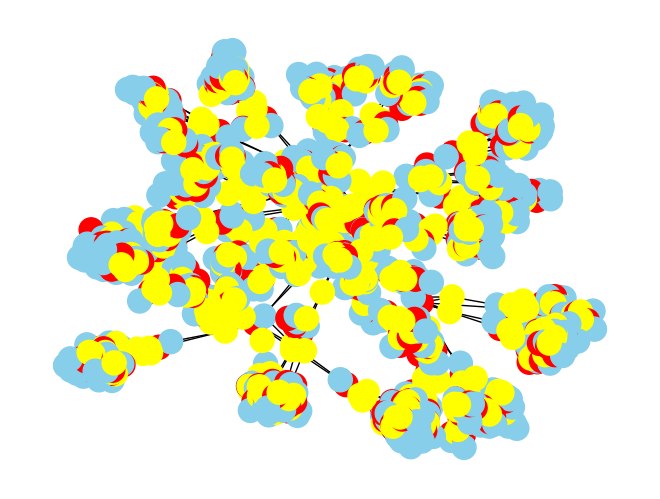

<Figure size 500x500 with 0 Axes>

In [32]:

# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"] # Bør ikke være noen
    #
#

pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))


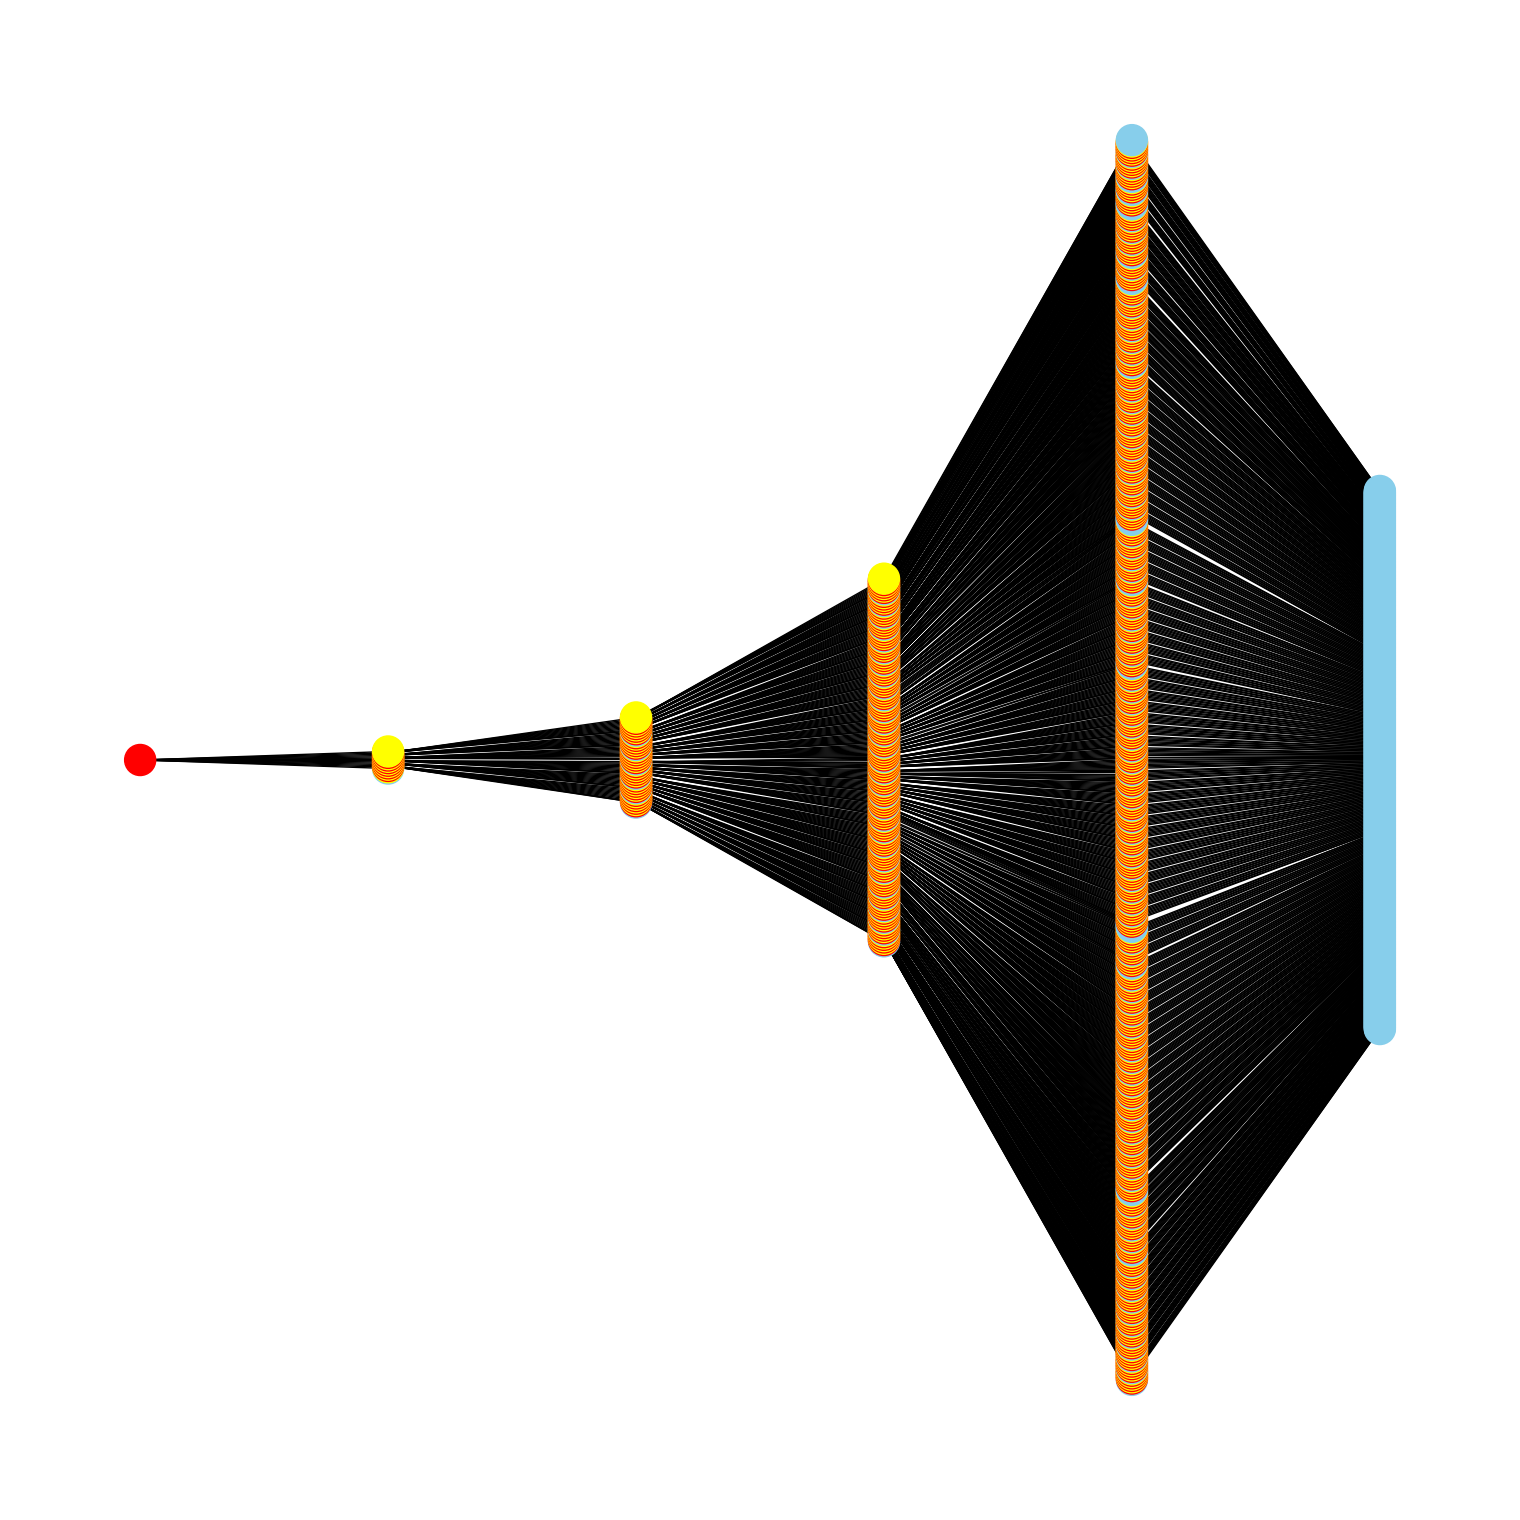

In [33]:

node_farge= []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#

# Vis frem
pos = nx.bfs_layout(G, start=bakmann)
plt.figure(figsize=(15, 15))

nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=500)
plt.show()